<a href="https://colab.research.google.com/github/drawcodeboy/Cat_n_Dog_Classification/blob/main/cat_vs_dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 라이브러리 불러오기
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow import keras
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
from PIL import Image

In [3]:
# 데이터 불러오기
# Dataset 출처 (https://www.kaggle.com/datasets/tongpython/cat-and-dog)
# 구글 드라이브에 업로드하여 사용

train_path = '/content/drive/MyDrive/training_set/training_set'
test_path = '/content/drive/MyDrive/test_set/test_set'

#os.listdir()
>* 해당 경로에 몇 개의 파일 또는 디렉터리가 존재하는지 확인
#os.endswith()
>* 특정 확장자를 지정(문자열)을 지정하여 어떤 파일 특정 확장자로 끝나는지 확인

In [4]:
print(os.listdir(train_path))
print(os.listdir(test_path))

['cats', 'dogs']
['cats', 'dogs']


# plt.imread()


(-0.5, 497.5, 414.5, -0.5)

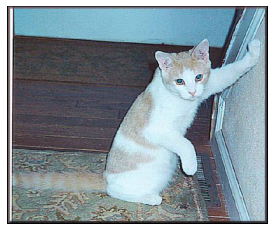

In [5]:
# test_set에서 그림 불러오기
plt.imshow(plt.imread('/content/drive/MyDrive/test_set/test_set/cats/cat.4001.jpg'))
plt.axis('off')

# os.walk()
>* 하위의 폴더들을 for문으로 탐색할 수 있게 한다. 인자로 전달된 path에 대해 3개의 값이 있는 tuple을 넘겨준다.
>* first(root): dir과 files가 있는 path
>* second(dirs): root 아래에 있는 폴더들
>* third(files): root 아래에 있는 파일들
# os.path.join()
>* 인수에 전달된 2개의 문자열을 결합하여, 1개의 경로로 할 수있다.

https://codechacha.com/ko/python-walk-files/

In [6]:
test_list = [] # test_set의 파일 경로들을 담은 리스트
test_target = []

for dirname, _, filenames in os.walk(test_path):
    #print(filenames)
    for filename in filenames:
        #print(filename)
        if(filename.endswith('jpg')): # 확장자가 jpg인 것만 담아주기
            if(filename[0] == 'c'):
                test_target.append(0)
            elif(filename[0] == 'd'):
                test_target.append(1)
            test_count = os.path.join(dirname, filename)
            test_list.append(test_count)

In [7]:
train_list = []
train_target = []

for dirname, _, filenames in os.walk(train_path):
    for filename in filenames:
        if(filename.endswith('jpg')):
            if(filename[0] == 'c'):
                train_target.append(0)
            elif(filename[0] == 'd'):
                train_target.append(1)
            train_count = os.path.join(dirname, filename)
            train_list.append(train_count)

(-0.5, 328.5, 499.5, -0.5)

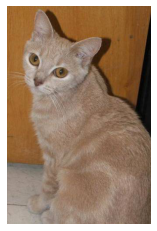

In [8]:
plt.imshow(plt.imread(train_list[1]))
plt.axis('off')

# 경로에서 이미지 데이터 가져오기 (Try 1)

## PIL(pillow) 모듈 : 이미지 처리 모듈
>* Image 패키지
>* Image.open(path)를 통해 그림을 가져와서 numpy로 바꿀 수 있다. -> 너무 오래 걸림
>* https://ddolcat.tistory.com/690

In [9]:
# 이미지 10개 정도 train_set에서 순차적으로 골라서 shape 확인
"""
fig, ax = plt.subplots(2, 5)

for i, jpg_path in enumerate(train_list):
    if(i == 10):
        break
    img = Image.open(jpg_path)
    ax[i // 5][i % 5].imshow(img)
    img_array = np.array(img)
    print(img_array.shape)

plt.show()
"""
# 이미지마다 shape가 각각 다 다르다 -> 같게 해줄 필요가 있다.

'\nfig, ax = plt.subplots(2, 5)\n\nfor i, jpg_path in enumerate(train_list):\n    if(i == 10):\n        break\n    img = Image.open(jpg_path)\n    ax[i // 5][i % 5].imshow(img)\n    img_array = np.array(img)\n    print(img_array.shape)\n\nplt.show()\n'

In [10]:
# 경로에서 PIL을 통해 Image를 가져와서 넘파이로 변환 후, train_set에 넣는 작업을 시도함

# >> 이 방식은 너무 오래 걸림
"""
train_set = []

for i, jpg_path in enumerate(train_list):
    print('counting... {}'.format(i))
    img = Image.open(jpg_path)
    img_array = np.array(img)
    train_set.append(img_array)

test_set = []

for i, jpg_path in enumerate(test_list):
    print('counting... {}'.format(i))
    img = Image.open(jpg_path)
    img_array = np.array(img)
    test_set.append(img_array)
"""

"\ntrain_set = []\n\nfor i, jpg_path in enumerate(train_list):\n    print('counting... {}'.format(i))\n    img = Image.open(jpg_path)\n    img_array = np.array(img)\n    train_set.append(img_array)\n\ntest_set = []\n\nfor i, jpg_path in enumerate(test_list):\n    print('counting... {}'.format(i))\n    img = Image.open(jpg_path)\n    img_array = np.array(img)\n    test_set.append(img_array)\n"

# 경로에서 이미지 데이터 가져오기 (Try 2)
##Keras로 이미지 데이터 불러오기

>* image.load_img(경로 문자열, 사이즈)
>* 불러오면서 resize까지 시켜서 편함

https://m.blog.naver.com/PostView.naver?isHttpsRedirect=true&blogId=baek2sm&logNo=221400912923

In [11]:
# get Data from Path and Transform(Resize)
# 이것도 오래 걸림

"""
from tensorflow.keras.preprocessing import image

train_set = []

for i, f in enumerate(train_list):
    img = image.load_img(f, target_size = (224, 224, 3)) # 반환형 <class 'PIL.Image.Image'>
    print('count {}'.format(i))
    img_np = np.array(img)
    train_set.append(img_np)
"""

"\nfrom tensorflow.keras.preprocessing import image\n\ntrain_set = []\n\nfor i, f in enumerate(train_list):\n    img = image.load_img(f, target_size = (224, 224, 3)) # 반환형 <class 'PIL.Image.Image'>\n    print('count {}'.format(i))\n    img_np = np.array(img)\n    train_set.append(img_np)\n"

In [12]:
"""
test_set = []

for f in test_list:
    img = image.load_img(f, target_size=(224, 224, 3))
    img_np = np.array(img)
    test_set.append(img)
"""

'\ntest_set = []\n\nfor f in test_list:\n    img = image.load_img(f, target_size=(224, 224, 3))\n    img_np = np.array(img)\n    test_set.append(img)\n'

# 경로에서 이미지 데이터 가져오기 (Try 3)
## tf.keras.preprocessing.image_dataset_from_directory

>* 4초만에 끝..

In [13]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

train_ds = image_dataset_from_directory(
    directory = '/content/drive/MyDrive/training_set/training_set',
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    image_size = (224, 224)
)

Found 8005 files belonging to 2 classes.


In [14]:
type(train_ds)

tensorflow.python.data.ops.dataset_ops.BatchDataset

# Pytorch ImageFolder
>* cat이랑 dog split하는 방법 찾다가 pytorch ImageFolder 사용하는 법
>* => 파일 받아올 때 해결해버림 (안 씀)

https://ndb796.tistory.com/373

https://dacon.io/codeshare/4750

## 쓴 방법
>* 애초에 데이터 경로를 받아오는 train_list, test_list에서 받는 과정에 경로가 'c'로 시작하면 target에 0을, 'd'로 시작하면 target에 1을 넣도록 처리해뒀다.

In [15]:
"""
# train, validation SPLIT

from sklearn.model_selection import train_test_split

train_set, val_set, train_target, val_target = train_test_split(
    train_set, train_target, test_size=0.02, random_state=42
)
"""

'\n# train, validation SPLIT\n\nfrom sklearn.model_selection import train_test_split\n\ntrain_set, val_set, train_target, val_target = train_test_split(\n    train_set, train_target, test_size=0.02, random_state=42\n)\n'

# Modeling

In [16]:
model = keras.Sequential()
model.add(keras.layers.Conv2D(32, kernel_size=3, activation='relu', padding = 'same', input_shape=(224, 224, 3)))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Conv2D(64, kernel_size=3, activation='relu', padding = 'same'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(50, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 flatten (Flatten)           (None, 200704)            0         
                                                                 
 dense (Dense)               (None, 50)                1

# 에러 난 부분
>* train을 시키는 데이터나 타깃의 type이 numpy가 아닌 list로 들어가서 났던 오류 타입 변환해서 넣어주면 된다.

Failed to find data adapter that can handle input: <class 'numpy.ndarray'>, (<class 'list'> containing values of types {"<class 'int'>"})

=> https://stackoverflow.com/questions/58682026/failed-to-find-data-adapter-that-can-handle-input-class-numpy-ndarray-cl

=> list 형태의 data_set을 numpy형태로 변환이 필요하다.

In [20]:
%%time

history = model.fit(train_ds, epochs=20)

Epoch 1/20
251/251 [==============================] - 78s 83ms/step - loss: 19.3846 - accuracy: 0.4926
Epoch 2/20
251/251 [==============================] - 22s 86ms/step - loss: 0.6899 - accuracy: 0.5029
Epoch 3/20
251/251 [==============================] - 21s 83ms/step - loss: 0.6735 - accuracy: 0.5626
Epoch 4/20
251/251 [==============================] - 22s 85ms/step - loss: 0.6388 - accuracy: 0.6224
Epoch 5/20
251/251 [==============================] - 22s 85ms/step - loss: 0.6157 - accuracy: 0.6553
Epoch 6/20
251/251 [==============================] - 22s 84ms/step - loss: 0.5728 - accuracy: 0.6936
Epoch 7/20
251/251 [==============================] - 22s 84ms/step - loss: 0.5480 - accuracy: 0.7164
Epoch 8/20
251/251 [==============================] - 21s 83ms/step - loss: 0.5158 - accuracy: 0.7355
Epoch 9/20
251/251 [==============================] - 22s 84ms/step - loss: 0.4636 - accuracy: 0.7735
Epoch 10/20
251/251 [==============================] - 21s 83ms/step - loss: 0.43

In [31]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    directory = '/content/drive/MyDrive/test_set/test_set',
    labels = 'inferred',
    label_mode = 'binary',
    batch_size = 32,
    image_size = (224, 224)
)

Found 2023 files belonging to 2 classes.


In [32]:
eval = model.evaluate(test_ds)

64/64 [==============================] - 229s 3s/step - loss: 1.2031 - accuracy: 0.6303
[1.2031456232070923, 0.6302521228790283]


In [33]:
print(eval)

[1.2031456232070923, 0.6302521228790283]
